# Validate different scenarios against each other - Regional

In [1]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely import geometry
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap, ScalarMappable
import contextily as cx
from quetzal.model import stepmodel
from quetzal.io import excel

C:\Users\m.arnz\AppData\Local\miniforge-pypy3\envs\quetzal\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-04-15 05:22:01,956	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


## Scenario settings

In [2]:
# Choose scenarios
scenario_ref = 'reference'
scenarios = [scenario_ref] + ['Reactivation', 'Shift', 'Reactivation+Shift']

In [3]:
input_path = '../input/'
network_path = '../input_static/'
output_path = '../output/'
model_path = '../model/'
params = excel.read_var(file='../input/parameters.xls', scenario=scenario_ref)
segments = [s.strip() for s in params['general']['demand_segments'].split(';')]
purposes = [s.split('_')[0] for s in segments][::2]

In [4]:
# Load model zones
ref = stepmodel.read_json(model_path + scenario_ref + '/de_zones')
ref.zones = gpd.GeoDataFrame(ref.zones, crs=ref.epsg)

In [5]:
# Choose region
# DE115 and DE149 are interesting for rail reactivation
region_name = 'Stuttgart_region'
region_nuts = 'DE115'
zone_ids = list(ref.zones.loc[ref.zones['NUTS_ID']==region_nuts, 'FID'])
polygon = ref.zones.loc[zone_ids, 'geometry'].unary_union
# Get region boundary coords
xx,yy = polygon.envelope.exterior.coords.xy
x0 = xx[0]
x1 = xx[1]
y0 = yy[0]
y1 = yy[2]

C:\Users\m.arnz\AppData\Local\Temp\ipykernel_18504\3261427526.py:6: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  polygon = ref.zones.loc[zone_ids, 'geometry'].unary_union


In [6]:
# All regions near reactivated railway line
all_zone_ids = [int(i) for i in '10010000;10020000;10040000;10510011;10530032;10530100;10535323;10535358;10545489;10550028;10560048;10560049;10565690;10570001;10570008;10570091;10575727;10575755;10575782;10575785;10580034;10580135;10585833;10590183;10595952;10605005;10610113;10615138;10615179;10615189;20000000;31010000;31020000;31510040;31515402;31515406;31540019;31540028;31550003;31550013;31570008;32520001;32520005;32555408;32555409;32559502;32570028;32570031;32570035;32575401;32575404;32575405;33510004;33510006;33510026;33530040;33535401;33535402;33535405;33535406;33545406;33550001;33550009;33550022;33555401;33555405;33555406;33555407;33560007;33560011;33570008;33570016;33570039;33575403;33575404;33575405;33575406;33575408;33580002;33580024;33590038;33595402;33595406;33610003;33610005;33610012;34040000;34520001;34520019;34520023;34520027;34525403;34560001;34560015;34565401;34565402;34590004;34590005;34610007;34625401;40120000;51120000;51140000;51160000;51190000;51200000;51240000;51540024;51540036;51540040;51540048;51540056;51580012;51580028;51580032;51580036;51620016;51620020;51620024;51660036;51700008;51700024;51700028;51700032;51700044;51700048;51700052;53140000;53150000;53340002;53340004;53340008;53340012;53340032;53340036;53580004;53580024;53580036;53620004;53620016;53620040;53660020;53660024;53660036;53700020;53700036;53700040;53740004;53740008;53740012;53740016;53740024;53740028;53740032;53740040;53740044;53740048;53740052;53780004;53780024;53780032;53820012;53820028;53820044;53820056;53820060;53820068;55150000;55540008;55540012;55540016;55540020;55540048;55540064;55580012;55580040;55660016;55660028;55660040;55660044;55660048;55660056;55660060;55660076;55660084;55660088;55660092;55700004;55700008;55700020;55700040;55700048;57540008;57540016;57540044;57540048;57660012;57660024;57660044;57740012;57740016;57740024;57740032;57740036;59540008;59540012;59540016;59540024;59540028;59580004;59580012;59580044;59620016;59620040;59660008;59660024;59740004;59740016;59740028;59740044;64110000;64120000;64140000;64320004;64320008;64320009;64320011;64320019;64320020;64320023;64330011;64340004;64350001;64350027;64350029;64359200;64380009;64390001;64390002;64390006;64390015;64400024;65310001;65310008;65310010;65310013;65310015;65310017;65310018;65320003;65320005;65320006;65320009;65320018;65320021;65320022;65330008;65330017;65330018;65340001;65340003;65340011;65340013;65340018;65340020;65350005;65350009;66110000;66320009;66320010;66320016;66320020;66330003;66330012;66330015;66330017;66330020;66330023;66340004;66340009;66340011;66340013;66340014;66340022;66360006;66369200;71110000;71315001;71315002;71325010;71335010;71335011;71345002;71355002;71355003;71370068;71370203;71375002;71375008;71385003;71385005;71405004;71405008;71415003;71415011;71435003;71435005;71435007;71435010;72110000;72335001;72335004;72335006;72355001;72355003;72355006;72355007;73130000;73315003;73325007;73335003;73335004;73335006;73340007;73345001;73345005;73365008;73375004;73375007;73395008;73405001;73405002;73405004;81110000;81150041;81150050;81150052;81155001;81160077;81160078;81165001;81165008;81170010;81175003;81175004;81175005;81175008;81175009;81175011;81180003;81180011;81180021;81180046;81180048;81180050;81180051;81180060;81180076;81180080;81185002;81185005;81185006;81185007;81185008;81190061;81195001;81195005;81210000;81255002;81255003;81255005;81255006;81255010;81255012;81255014;81265001;81265003;81265004;81270008;81275004;81350015;81365007;82110000;82120000;82150064;82150084;82150102;82155003;82165005;82165006;82210000;82220000;82255002;82255003;82255005;82255006;82260062;82260063;82260084;82260105;82265008;82265009;82355002;82355006;82375003;83155002;83170057;83170153;83255003;83355005;83355006;83360014;83360091;83365001;83365003;83365007;83365008;83370106;83370116;83375005;84150059;84150061;84150092;84155001;84165003;84170025;84175001;84175002;84175004;84175006;84255009;84360008;84365001;84370086;84375002;84375003;84375004;84375006;91710127;91720116;91720117;91720124;91720132;91729454;91760114;91760137;91770115;91770137;91770139;91810113;91810128;91810130;91815138;91815139;91815142;91830128;91835149;91835152;91870113;91870116;91870124;91870128;91870176;91870182;91875162;91895170;91900148;91905174;92610000;92620000;92720118;92720141;92720151;92725214;92730137;92735216;92735217;92740113;92740172;92740176;92745221;92750128;92750135;92750144;92750146;92750151;92755229;92770121;92790115;92790126;93730112;93730146;93730147;93735321;93750196;93755337;93760119;93760141;93760170;93770154;93770158;93775347;93775351;94630000;94730120;94730141;94730159;94750112;94750156;94755428;94760152;95630000;95640000;95710136;95710145;95710193;95710200;95710214;95715501;95715502;95715508;95770136;96610000;96620000;96710122;96720113;96720163;96720166;96725606;96729457;96729458;96729466;96730117;96750141;96750158;96755614;96755615;96755619;96770155;96775624;96780135;96780138;96785642;96795645;96795647;97720131;97720141;97720167;97725708;97725709;97780116;97780137;97780169;97785760;97785764;97790147;97790194;97795720;97795721;100410100;100410512;100410515;100410517;100410519;100420112;100420113;100420116;100430111;100440111;100440112;100440113;100440116;100440117;100440119;100440120;100450112;100450114;100460114;100460115;110000000;120600269;120600280;120610219;120610260;120610316;120610320;120610332;120610540;120620224;120625031;120630148;120630208;120630252;120630357;120640029;120640227;120640317;120640336;120640512;120645403;120645414;120650096;120650136;120650144;120650165;120650193;120650225;120650251;120650256;120660304;120665607;120670036;120670426;120675707;120680468;120690017;120690304;120690590;120690596;120690604;120690665;120695918;120700424;120705001;120705005;120705006;120710160;120720017;120720120;120720340;120720477;130030000;130715154;130715155;130715159;130720043;130725255;130725256;130725257;130725260;130730105;130735352;130735355;130755553;130755562;130760108;130765654;130765655;130765663;130765666;130765667;145110000;145210390;145210495;145220080;145220260;145220460;145220480;145220510;145220540;145225126;145230010;145230160;145230200;145230310;145230365;145235131;145245114;146250030;146250250;146260245;146260280;146260390;146260530;146270080;146270100;146270140;146270180;147130000;147290080;147290150;147290160;147300020;147300080;147300110;147300160;147305601;150030000;150820430;150840355;150845051;150845054;150860005;150860040;150860055;150860140;150870275;150870370;150870412;150875051;150875052;150880205;150880305;150880330;150890026;150910020;150910160;150910375;160540000;160620041;160630078;160630082;160630097;160630101;160630103;160635051;160650087;160655055;160670029;160675050;160675052;160675054;160680051;160680058;160680063;160685009;160690012;160690043;160695002;160700029;160700057;160705002;160715051;160720011;160725051;160730077;160735005;160750062;160750098;160750134;160750135;160750136;160755004;160755011;160755013;160755050;160760092'.split(';')]

## Plotting settings

In [7]:
# Plot fonts
import matplotlib
#matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'arial'

In [8]:
# Resolution of output plots
dpi = 500

In [9]:
# Define the mode colors
cmap_mode = get_cmap('CMRmap')
colormap = {'car':cmap_mode(.45), 'private_car':cmap_mode(.45), 'car_sharing':cmap_mode(.51),
            'rail':cmap_mode(.24), 'rail_long':cmap_mode(.31), 'rail_short':cmap_mode(.24),
            'coach':cmap_mode(.82), 'bus':cmap_mode(.72),
            'air':cmap_mode(.02), 'air_domestic':cmap_mode(.02),
            'non-motorised':'lightgray'#cmap_mode(.92)
           } # also defines mode order

C:\Users\m.arnz\AppData\Local\Temp\ipykernel_18504\419023608.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_mode = get_cmap('CMRmap')


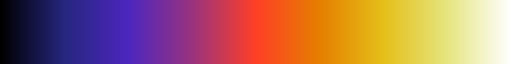

In [10]:
cmap_mode

In [11]:
# Colors and linestyles for each scenario (max four scenarios)
colors = {s: c for s,c in zip(scenarios, ['blue', 'purple', 'red', 'orange'][:len(scenarios)])}
linestyles = {s: l for s,l in zip(scenarios, ['-', ':', '--', '-.'][:len(scenarios)])}

In [12]:
# Load distances
distances = pd.read_csv(output_path + '/distances_centroids.csv')
distances = distances.set_index(['origin', 'destination'])

In [13]:
# Load the calibration dataset for validation
# if available
if False:
    mid2017 = pd.read_csv(input_path + 'transport_demand/calibration_all_trips_MiD2017.csv')
    # Replace LAU codes with NUTS IDs
    assert str(mid2017.loc[0, 'origin']).startswith('DE')
    # Rename modes and purposes
    mode_dict_mid = {1: 'rail_short', 2: 'rail_long',
                     3: 'coach', 4: 'bus', 5: 'air', 6: 'car', 7: 'walk'}
    mid2017['mode_model'] = mid2017['mode_model'].map(mode_dict_mid)
    mid2017['purpose_model'] = mid2017['purpose_model'].apply(lambda s: s.split('_')[0])
    mid2017['segment'] = mid2017['purpose_model'] + mid2017['car_avail'].map(
        {1: '_car', 0: '_no_car', 9: '_no_car'})
    mid2017 = mid2017[['mode_model', 'purpose_model', 'segment', 'origin', 'destination']]

# Networks

PT network and roads in the region

In [14]:
# Load PT networks
pt_links = {}
pt_nodes = {}
for scenario in scenarios:
    try:
        sm = stepmodel.read_json(model_path + scenario + '/de_pt_network_agg')
    except FileNotFoundError:
        sm = stepmodel.read_json(model_path + 'base' + '/de_pt_network_agg')
    sm.nodes = gpd.GeoDataFrame(sm.nodes, crs=sm.epsg)
    sm.links = gpd.GeoDataFrame(sm.links, crs=sm.epsg)
    sm.nodes = sm.nodes.loc[sm.nodes['geometry'].within(polygon.buffer(0.1))]
    sm.links = sm.links.loc[sm.links['a'].isin(sm.nodes.index)]
    pt_links[scenario] = sm.links.copy()
    pt_nodes[scenario] = sm.nodes.copy()
    del sm

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


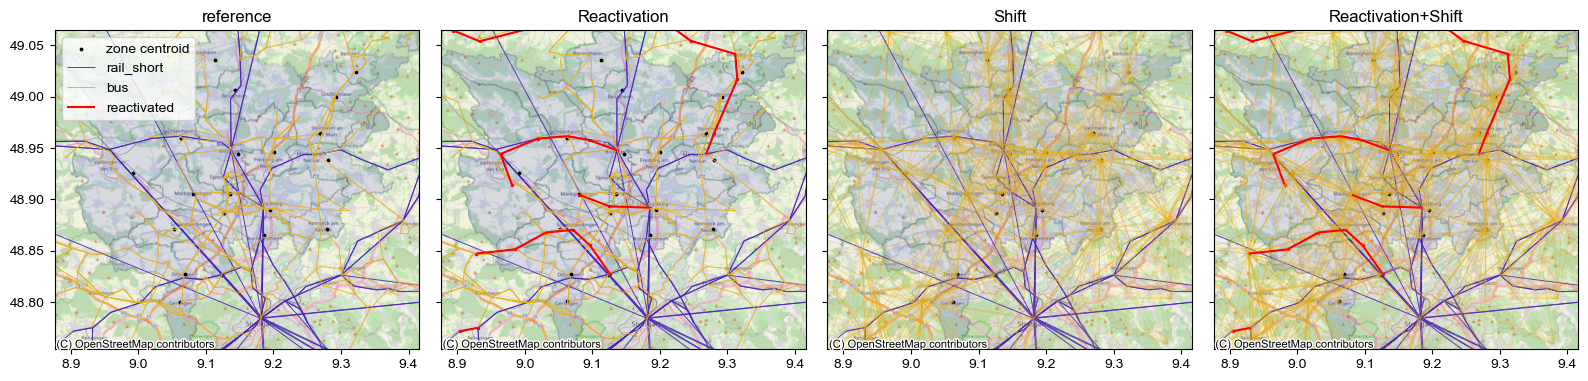

In [15]:
# Plot networks
fig, axs = plt.subplots(nrows=1, ncols=len(scenarios), figsize=(4*len(scenarios),4),
                        sharex='all', sharey='all')
for s,ax in zip(scenarios, axs):
    ax.set_xlim(x0,x1)
    ax.set_ylim(y0,y1)
    # Zones
    ref.zones.loc[zone_ids].plot(color='blue', alpha=.1, edgecolor='black', ax=ax)
    # Centroids
    c = gpd.GeoDataFrame(geometry=[geometry.Point(x,y) for (x,y) in ref.zones.loc[zone_ids, ['lat', 'lon']].values], crs=4326)
    c.plot(color='black', label='zone centroid', markersize=3, ax=ax)
    # Links
    l = pt_links[s].drop_duplicates('geometry')
    l = l.loc[l['route_type']!='rail_long']
    l = l.loc[l['route_type']!='coach']
    l = l.loc[l['route_type']!='air']
    for mode in l['route_type'].unique():
        alpha = .9
        if mode=='bus' and 'Shift' in s: alpha=.2
        l.loc[l['route_type']==mode, 'geometry'].plot(color=colormap[mode], label=mode, linewidth=.7, alpha=alpha, ax=ax)
    # Reactivation links
    if 'Reactivation' in s:
        l_reac = l.loc[l.index.str.contains('reac')]
        l_reac.plot(color='red', label='reactivated', ax=ax)
        pt_nodes[s].loc[pt_nodes[s].index.isin(set(list(l_reac['a'])+list(l_reac['b'])))
                        ].plot(color='red', markersize=2.1, ax=ax)
    try:
        cx.add_basemap(ax=ax, crs=4326, zoom=11, source=cx.providers.OpenStreetMap.DE)
    except HTTPError:
        pass
    ax.set_title(s)
h,l = axs[1].get_legend_handles_labels()
axs[0].legend(h,l, loc='upper left')
fig.tight_layout()
plt.savefig(output_path + '_scenario_validation_regional/'+region_name+'_networks_pt.png', dpi=dpi)
plt.savefig(output_path + '_scenario_validation_regional/'+region_name+'_networks_pt.eps')

# Composite cost

Percieved cost averaged over all modes by origin-destination pair

For region of interest

In [16]:
# Load CC
cc = {}
for scenario in scenarios:
    df = pd.read_csv(output_path + scenario + '/mode_choice_od_composite_cost.csv')
    df = df.loc[df['origin'].isin(zone_ids)]
    cc[scenario] = df

In [17]:
# Define distance classes
#bins = [0, 20, 40, 60, 80, 100, 150, 200, 300, 500, 700, 1000]
#labels = ['{}-{}km'.format(bins[i], bins[i+1]) for i in range(len(bins)-1)]
bins = list(range(0,1020, 10))
labels = bins[:-1]
for scenario in scenarios:
    cc[scenario]['dist'] = cc[scenario].set_index(['origin', 'destination']).index.map(distances.to_dict()['length'])
    cc[scenario]['bins'] = pd.cut(cc[scenario]['dist'], bins=bins, labels=labels)

C:\Users\m.arnz\AppData\Local\Temp\ipykernel_18504\2167991557.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cc[scenario].notna().all(axis=1)].groupby('bins')[seg].mean(),


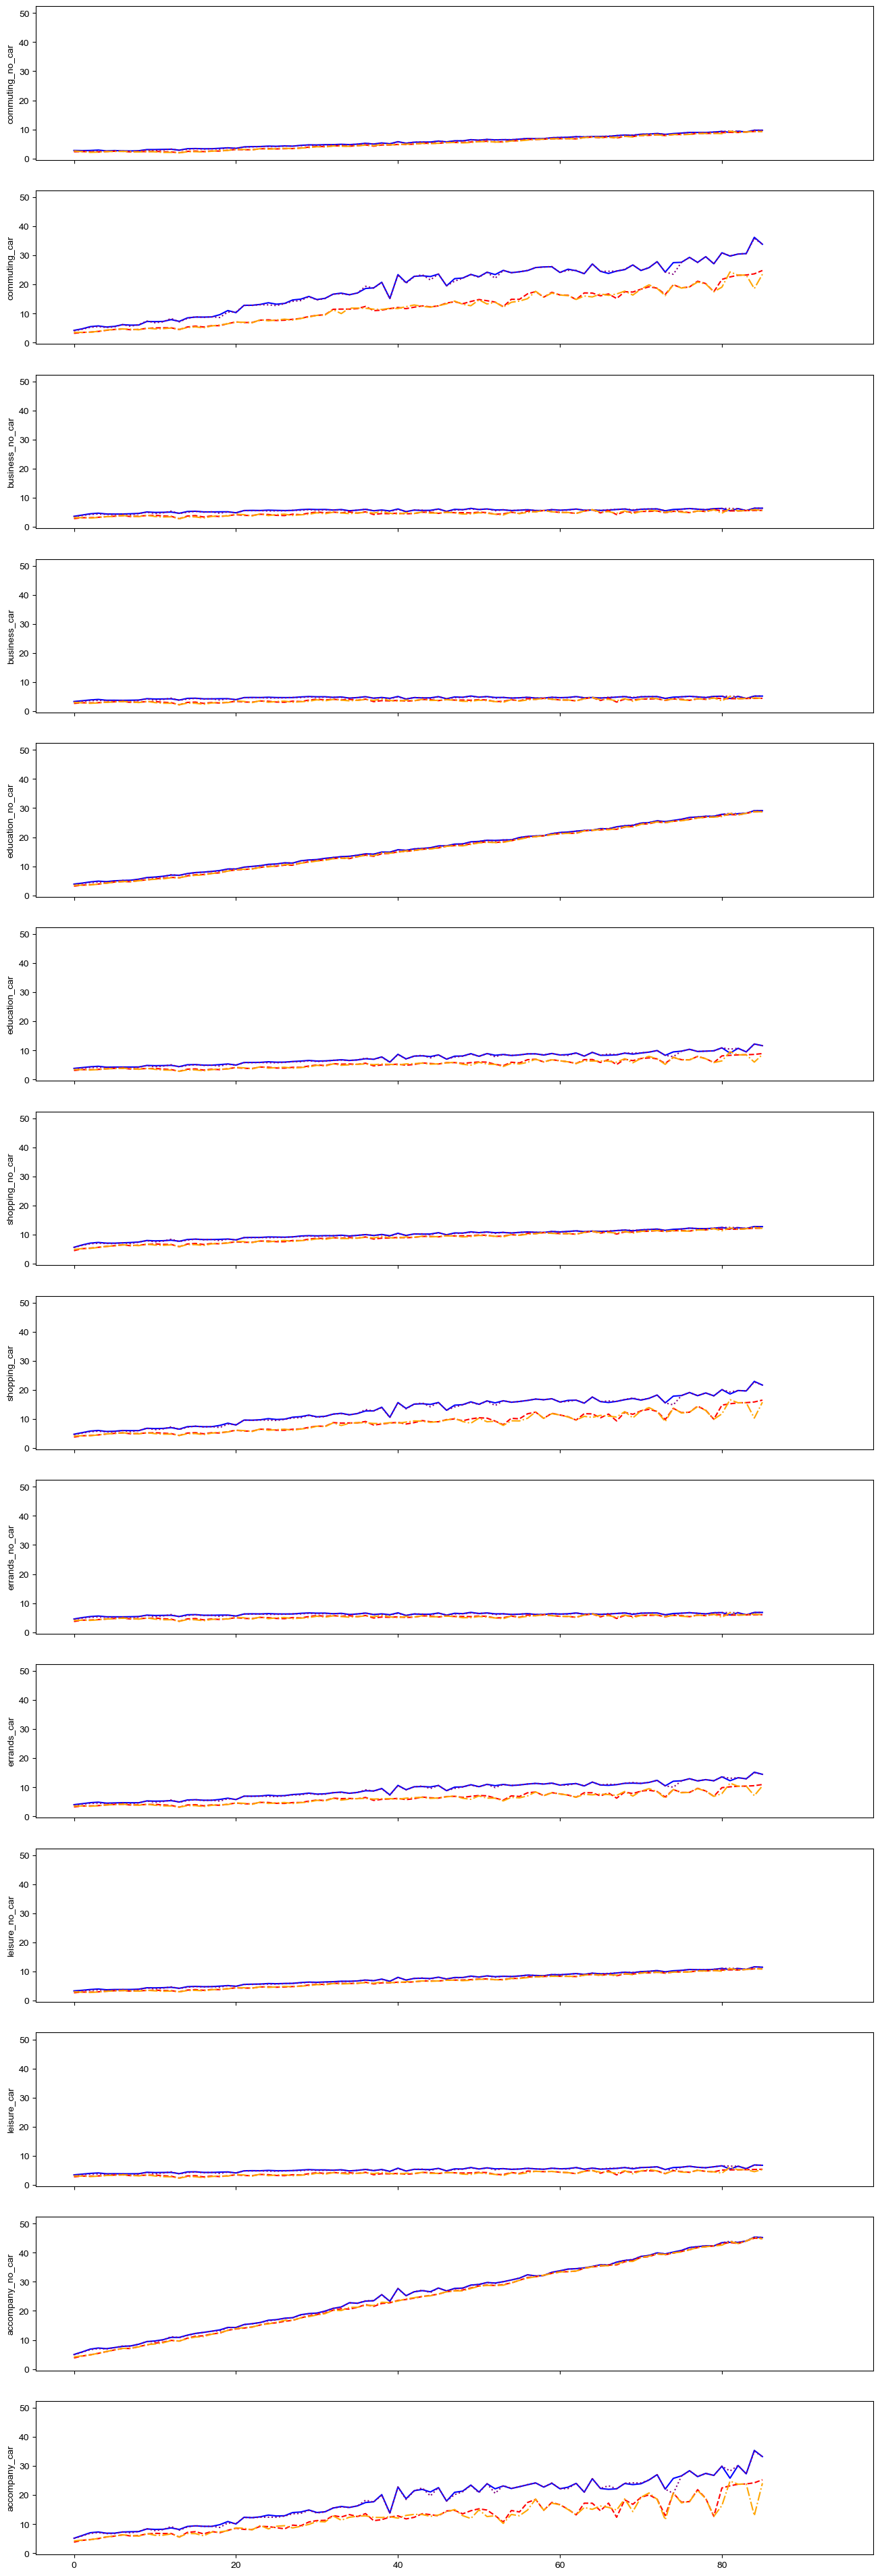

In [18]:
fig, ax = plt.subplots(nrows=len(segments), ncols=1, figsize=(16, 3.5*len(segments)),
                       sharex='all', sharey='all')
i = 0
for seg in segments:
    for scenario in scenarios:
        ax[i].plot(np.arange(len(labels)), cc[scenario].loc[
            cc[scenario].notna().all(axis=1)].groupby('bins')[seg].mean(),
                  color=colors[scenario], linestyle=linestyles[scenario])
    ax[i].set_ylabel(seg)
    i += 1

C:\Users\m.arnz\AppData\Local\Temp\ipykernel_18504\3175896882.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_cc = cc[scenario].loc[cc[scenario].notna().all(axis=1)].groupby('bins')[segments].mean().mean(axis=1)
C:\Users\m.arnz\AppData\Local\Temp\ipykernel_18504\3175896882.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_cc = cc[scenario].loc[cc[scenario].notna().all(axis=1)].groupby('bins')[segments].mean().mean(axis=1)
C:\Users\m.arnz\AppData\Local\Temp\ipykernel_18504\3175896882.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version

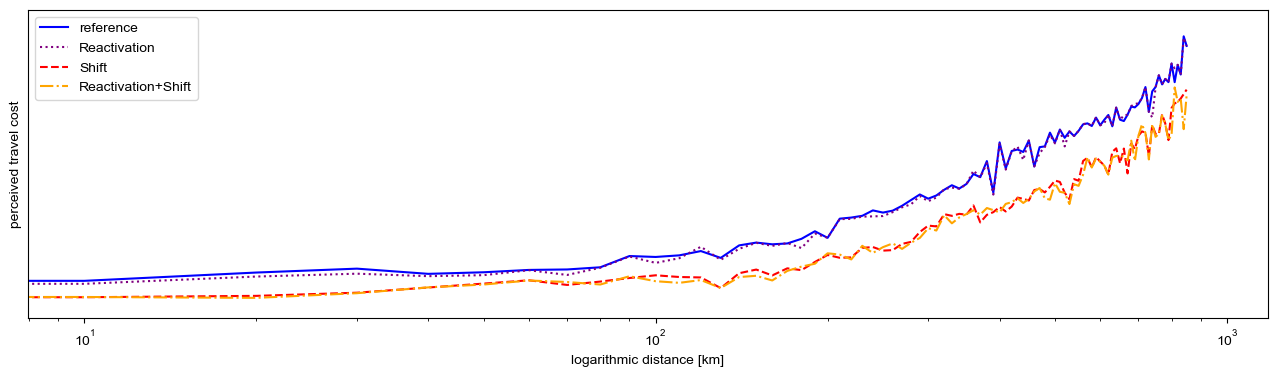

In [19]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(16,4),
                       sharex='all', sharey='row')
ind = labels
for scenario in scenarios:
    mean_cc = cc[scenario].loc[cc[scenario].notna().all(axis=1)].groupby('bins')[segments].mean().mean(axis=1)
    ax.plot(ind, mean_cc, label=scenario, color=colors[scenario], linestyle=linestyles[scenario])
ax.set_ylabel('perceived travel cost')
ax.set_yticks([])
ax.set_xscale('log')
ax.set_xlabel('logarithmic distance [km]')
ax.legend(loc='upper left')
plt.savefig(output_path + '_scenario_validation_regional/'+region_name+'_cc_all_distance.png', dpi=dpi)

C:\Users\m.arnz\AppData\Local\Temp\ipykernel_18504\4204805534.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ].groupby('bins')[segments].mean().mean(axis=1)
C:\Users\m.arnz\AppData\Local\Temp\ipykernel_18504\4204805534.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ].groupby('bins')[segments].mean().mean(axis=1)
C:\Users\m.arnz\AppData\Local\Temp\ipykernel_18504\4204805534.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence

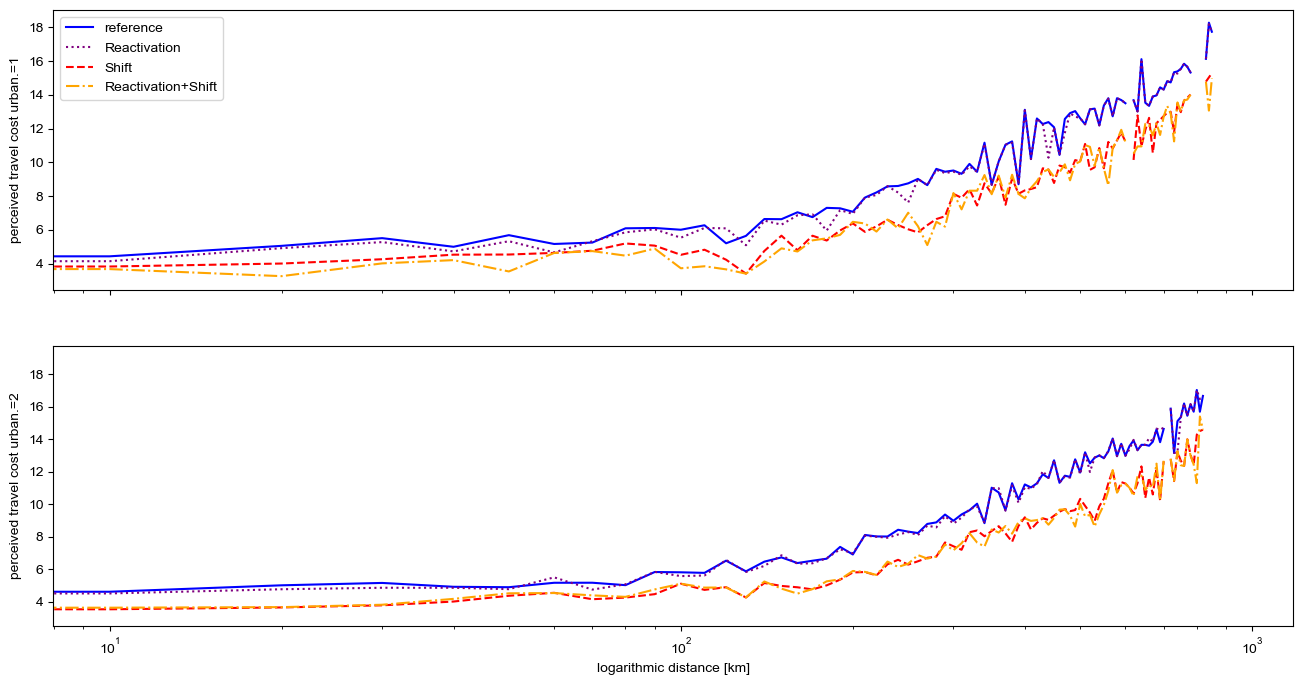

In [20]:
# By urbanisation
urb = list(ref.zones.loc[zone_ids, 'urbanisation'].unique())
urb.sort()
fig, ax = plt.subplots(nrows=len(urb), ncols=1, figsize=(16,4*len(urb)),
                       sharex='all', sharey='row')
ind = labels
for u in urb:
    zones = list(ref.zones.loc[ref.zones['urbanisation']==u].index)
    for scenario in scenarios:
        mean_cc = cc[scenario].loc[(cc[scenario].notna().all(axis=1)) & (cc[scenario]['origin'].isin(zones))
                                  ].groupby('bins')[segments].mean().mean(axis=1)
        ax[u-1].plot(ind, mean_cc, label=scenario, color=colors[scenario], linestyle=linestyles[scenario])
    ax[u-1].set_ylabel('perceived travel cost urban.={}'.format(u))
    ax[u-1].set_xscale('log')
ax[0].legend(loc='upper left')
ax[-1].set_xlabel('logarithmic distance [km]')
plt.savefig(output_path + '_scenario_validation_regional/'+region_name+'_cc_all_distance_urbanisation.png', dpi=dpi)

# Volumes

Number of trips per year

For region of interest, all zones near reactivation, and Germany

In [21]:
# Load volumes
vols = {}
vols_region = {}
vols_regions_all = {}
for scenario in scenarios:
    distr = stepmodel.read_zippedpickles(model_path + scenario + '/de_volumes_distribution')
    if len(set(segments) - set(distr.volumes.columns)) == 0:
        vols[scenario] = distr.volumes
    else:
        choice = stepmodel.read_zippedpickles(model_path + scenario + '/de_volumes_choice')
        vols[scenario] = pd.merge(choice.volumes, distr.volumes, how='outer', on=['origin', 'destination']).reset_index(drop=True)
    vols_region[scenario] = vols[scenario].loc[vols[scenario]['origin'].isin(zone_ids)]
    vols_regions_all[scenario] = vols[scenario].loc[vols[scenario]['origin'].isin(all_zone_ids)]

volumes: 100%|███████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  4.21it/s]


### Distance distribution

inter-zonal trips

In [22]:
# Define distance classes
#bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 120, 150, 200, 300, 500, 1000]
#labels = ['{}-{}km'.format(bins[i], bins[i+1]) for i in range(len(bins)-1)]
bins = list(range(0,1020, 10))
labels = bins[:-1]
for scenario in scenarios:
    for extent in [vols, vols_region, vols_regions_all]:
        vol = extent[scenario]
        vol['dist'] = vol.set_index(['origin', 'destination']).index.map(distances.to_dict()['length'])
        vol['dist'] = vol['dist'].clip(lower=.1)
        vol['bins'] = pd.cut(vol['dist'], bins=bins, labels=labels)

C:\Users\m.arnz\AppData\Local\Temp\ipykernel_18504\926883630.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vol['dist'] = vol.set_index(['origin', 'destination']).index.map(distances.to_dict()['length'])
C:\Users\m.arnz\AppData\Local\Temp\ipykernel_18504\926883630.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vol['dist'] = vol['dist'].clip(lower=.1)
C:\Users\m.arnz\AppData\Local\Temp\ipykernel_18504\926883630.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a

In [23]:
# Sum up volumes
vol_df = pd.DataFrame()
vol_region_df = pd.DataFrame()
vol_regions_all_df = pd.DataFrame()
for scenario in scenarios:
    for df, extent in zip([vol_df, vol_region_df, vol_regions_all_df], [vols, vols_region, vols_regions_all]):
        df[[scenario+' '+seg for seg in segments]] = extent[scenario].groupby('bins')[segments].sum()
        df[scenario] = df[[scenario+' '+seg for seg in segments]].sum(axis=1)
        df[scenario+' with car'] = df[[scenario+' '+seg for seg in segments if not '_no_car' in seg]].sum(axis=1)
        df[scenario+' without car'] = df[[scenario+' '+seg for seg in segments if '_no_car' in seg]].sum(axis=1)

C:\Users\m.arnz\AppData\Local\Temp\ipykernel_18504\1738533835.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[[scenario+' '+seg for seg in segments]] = extent[scenario].groupby('bins')[segments].sum()
C:\Users\m.arnz\AppData\Local\Temp\ipykernel_18504\1738533835.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[[scenario+' '+seg for seg in segments]] = extent[scenario].groupby('bins')[segments].sum()
C:\Users\m.arnz\AppData\Local\Temp\ipykernel_18504\1738533835.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=

C:\Users\m.arnz\AppData\Local\Temp\ipykernel_18504\2919665430.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('bins')[cols].mean().mean(axis=1)
C:\Users\m.arnz\AppData\Local\Temp\ipykernel_18504\2919665430.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('bins')[cols].mean().mean(axis=1)
C:\Users\m.arnz\AppData\Local\Temp\ipykernel_18504\2919665430.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warn

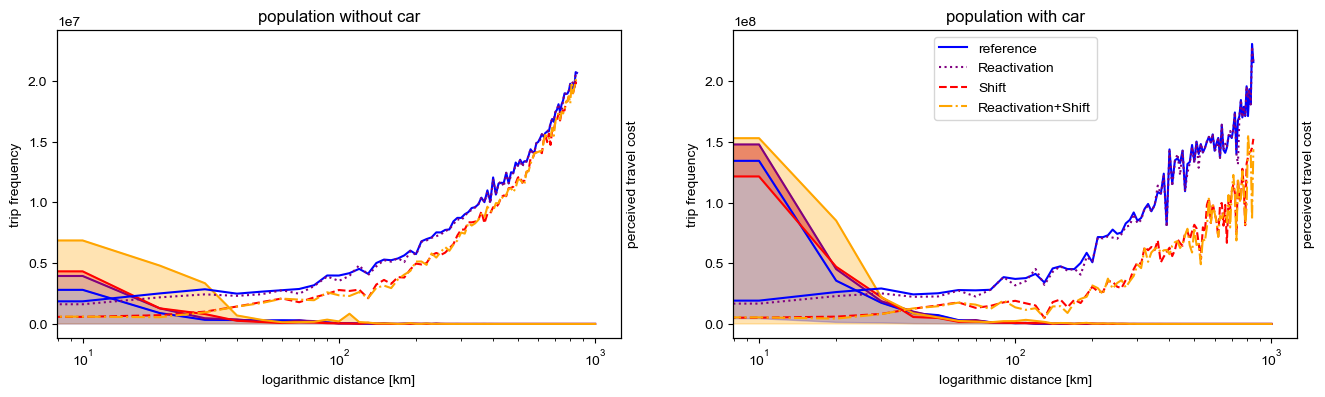

In [24]:
# plot with CC by car availability - regional
try:
    _ = cc[scenarios[0]] # is CC loaded?
    fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(16,4))
    ind = list(range(0,1020, 10))[:-1]
    prev_line = [0 for _ in ind]
    
    # Plot trip frequency
    for ax, seg in zip(axs, [' without car', ' with car']):
        ax.set_title('population'+seg)
        for scenario in scenarios:
            ax.plot(ind, vol_region_df[scenario+seg], color=colors[scenario])
            line_data = vol_region_df[scenario+seg]
            if line_data[0] > prev_line[0]:
                ax.fill_between(ind, prev_line, line_data, color=colors[scenario], alpha=.3)
                prev_line = vol_region_df[scenario+seg]
            else:
                ax.fill_between(ind, 0, line_data, color=colors[scenario], alpha=.3)
        ax.set_ylabel('trip frequency')
        ax.set_xlabel('logarithmic distance [km]')
        ax.set_xscale('log')

        # Add CC
        ax2 = ax.twinx()
        ax2.set_ylabel('perceived travel cost')
        ax2.set_yticks([])
        for scenario in scenarios:
            if 'without' in seg:
                cols = [s for s in segments if '_no_car' in s]
            else:
                cols = [s for s in segments if not '_no_car' in s]
            mean_cc = cc[scenario].loc[cc[scenario].notna().all(axis=1)]\
                .groupby('bins')[cols].mean().mean(axis=1)
            mean_cc[1000] = mean_cc[990]
            ax2.plot(ind, mean_cc, label=scenario,
                     color=colors[scenario], linestyle=linestyles[scenario])
    
    ax2.legend(loc='upper center')
    plt.savefig(output_path + '_scenario_validation_regional/'+region_name+'_distance_distribution_cc_car_ownership.png', dpi=dpi)
except:
    pass

# Modal split

by main mode. Inter-zonal and inner-zonal. All traffic originating from zones of interest.

In [51]:
# Load probabilities and merge with volumes to create an OD matrix
ods = {}
ods_region = {}
ods_regions_all = {}
for scenario in scenarios:
    # inter-zonal
    sm = stepmodel.read_zippedpickles(model_path + scenario + '/de_logit')
    od = sm.probabilities.set_index(['origin', 'destination', 'segment'])\
        .drop(columns=['root'], errors='ignore').unstack('segment')
    modes = set(od.columns.get_level_values(0))
    if len(['rail' for mode in modes if 'rail' in mode]) > 1:
        od.drop('rail', axis=1, inplace=True)
    if len(['car' for mode in modes if 'car' in mode]) > 1:
        od.drop('car', axis=1, inplace=True)
    vol = vols[scenario].loc[vols[scenario]['origin']!=vols[scenario]['destination']]
    vol[['origin', 'destination']] = vol[['origin', 'destination']].astype(str)
    vol = vol.set_index(['origin', 'destination']).drop(columns=['bins', 'dist', 'index'], errors='ignore')
    od_vols = pd.DataFrame(index=vol.index, columns=od.columns)
    for mode in set(od.columns.get_level_values(0)):
        od_vols[mode] = (od[mode] * vol).fillna(0)
    ods[scenario] = od_vols
    del sm
    # inner-zonal
    inner = pd.read_excel(output_path + scenario + '/inner_zone.xlsx', sheet_name='inner_zone')
    inner['origin'] = inner['origin'].astype(str)
    inner['destination'] = inner['origin']
    inner['mode'] = inner['mode'].replace({'rail': 'rail_short'})
    inner.rename(columns={'mode': 'route_type'}, inplace=True)
    inner = inner.set_index(['origin', 'destination', 'route_type', 'segment'])['volumes'].unstack(['route_type', 'segment'])
    # Consolidate
    ods[scenario] = pd.concat([od_vols, inner]).fillna(0)
    ods_region[scenario] = ods[scenario].loc[[str(i) for i in zone_ids]]
    ods_regions_all[scenario] = ods[scenario].loc[[str(i) for i in all_zone_ids]]

utility_values: 100%|████████████████████████████████████████████████████████████████████| 9/9 [00:15<00:00,  1.77s/it]
C:\Users\m.arnz\AppData\Local\Temp\ipykernel_18504\3741836129.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vol[['origin', 'destination']] = vol[['origin', 'destination']].astype(str)
utility_values: 100%|████████████████████████████████████████████████████████████████████| 9/9 [00:15<00:00,  1.74s/it]
C:\Users\m.arnz\AppData\Local\Temp\ipykernel_18504\3741836129.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


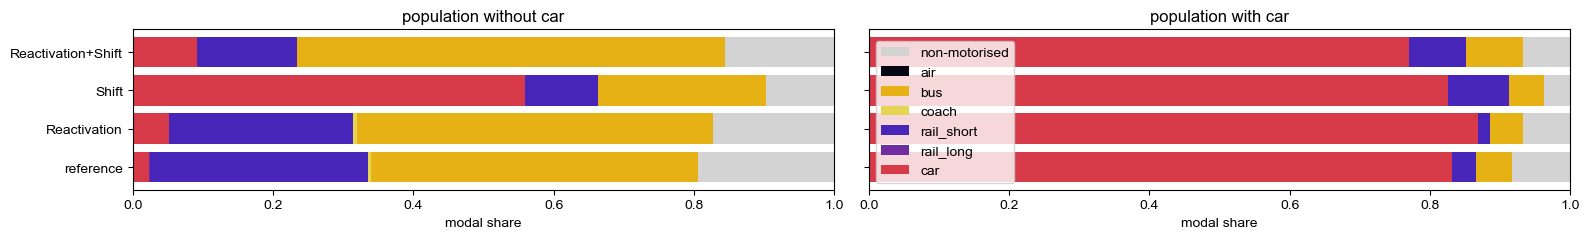

In [93]:
# Modal split within and between zones
# Horizontal stacked bar chart
fig, ax = plt.subplots(1,2, figsize=(16,2.5), layout='tight')
y_pos = range(len(scenarios))
without = [s for s in segments if '_no_car' in s]
with_car = [s for s in segments if not '_no_car' in s]
for i, segs, title in zip([0,1], [without, with_car], ['population without car', 'population with car']):
    left = [0] * len(y_pos)
    od_sums = {s: ods_region[s].loc[:, ods_region[s].columns.get_level_values('segment').isin(segs)].sum().sum() for s in scenarios}
    for label in list(colormap.keys()):
        mode = label if label != 'non-motorised' else 'walk'
        values = [ods_region[s][mode][segs].sum().sum() / od_sums[s]
                  if mode in ods_region[s].columns.get_level_values(0) else 0
                  for s in scenarios]
        if sum(values) > 0:
            ax[i].barh(y=y_pos, height=0.8, width=values, left=left, label=label, color=colormap[label])
            left = [l + v for l, v in zip(left, values)]
    ax[i].set_xlabel('modal share')
    ax[i].set_xlim((0,1))
    ax[i].set_title(title)

h,l = ax[1].get_legend_handles_labels()
ax[1].legend(h[::-1], l[::-1], loc='lower left')
ax[0].set_yticks(y_pos, scenarios)
ax[1].set_yticks(y_pos, [])

plt.savefig(output_path + '_scenario_validation_regional/'+region_name+'_modal_split_trips.png', dpi=dpi)
plt.savefig(output_path + '_scenario_validation_regional/'+region_name+'_modal_split_trips.eps')

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


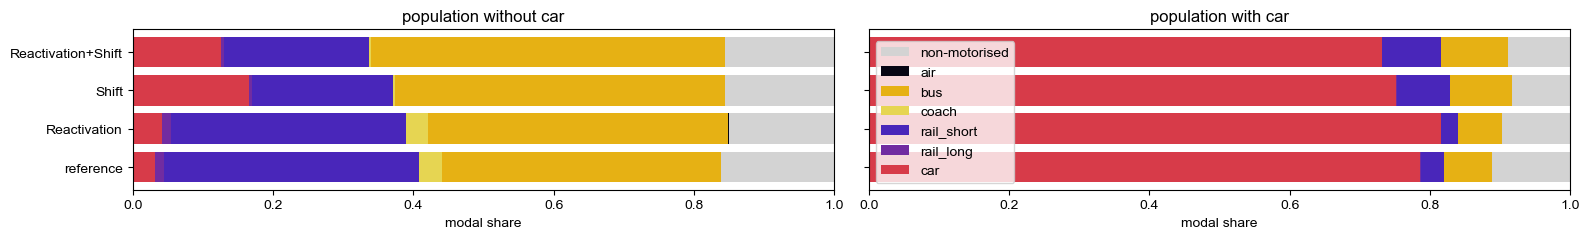

In [94]:
# Modal split within and between zones
# Horizontal stacked bar chart
# Germany
fig, ax = plt.subplots(1,2, figsize=(16,2.5), layout='tight')
y_pos = range(len(scenarios))
without = [s for s in segments if '_no_car' in s]
with_car = [s for s in segments if not '_no_car' in s]
for i, segs, title in zip([0,1], [without, with_car], ['population without car', 'population with car']):
    left = [0] * len(y_pos)
    od_sums = {s: ods[s].loc[:, ods[s].columns.get_level_values('segment').isin(segs)].sum().sum() for s in scenarios}
    for label in list(colormap.keys()):
        mode = label if label != 'non-motorised' else 'walk'
        values = [ods[s][mode][segs].sum().sum() / od_sums[s]
                  if mode in ods[s].columns.get_level_values(0) else 0
                  for s in scenarios]
        if sum(values) > 0:
            ax[i].barh(y=y_pos, height=0.8, width=values, left=left, label=label, color=colormap[label])
            left = [l + v for l, v in zip(left, values)]
    ax[i].set_xlabel('modal share')
    ax[i].set_xlim((0,1))
    ax[i].set_title(title)

h,l = ax[1].get_legend_handles_labels()
ax[1].legend(h[::-1], l[::-1], loc='lower left')
ax[0].set_yticks(y_pos, scenarios)
ax[1].set_yticks(y_pos, [])

plt.savefig(output_path + '_scenario_validation_regional/Germany_modal_split_trips.png', dpi=dpi)
plt.savefig(output_path + '_scenario_validation_regional/Germany_modal_split_trips.eps')

In [39]:
# Define distance classes
'''bins = [0, 20, 30, 40, 50, 60, 70, 80, 100, 200, 1000]
labels = ['<{}km'.format(bins[i+1]) for i in range(len(bins)-1)]
d = distances.reset_index()
d[['origin', 'destination']] = d[['origin', 'destination']].astype(str)
d = d.set_index(['origin', 'destination'], drop=True)
for s in scenarios:
    ods[s]['dist'] = ods[s]['car'].merge(d, how='left', left_index=True, right_index=True)['length']
    ods[s]['bins'] = pd.cut(ods[s]['dist'], bins=bins, labels=labels)
    ods[s].drop('dist', axis=1, inplace=True)'''
print(' ')

# Combined plots

Mode shares and trip frequencies for aggregated regions

In [ ]:
fig, axs = plt.subplots(nrows=8, ncols=2, figsize=(16,22), layout='tight')

# Trip frequency

# Mode share


# Passenger kilometre

pkm = #trips * distance

In [56]:
# Load pkm
pkm = {}
for s in scenarios:
    df = pd.read_csv(output_path + s + '/pkm_inter_main_mode.csv')
    df = df.groupby(['origin', 'mode'])['pkm'].sum().unstack('mode').fillna(0)
    pkm[s] = df#[[mode for mode in df.columns if df[mode].sum()>df.sum().sum()*0.001]]

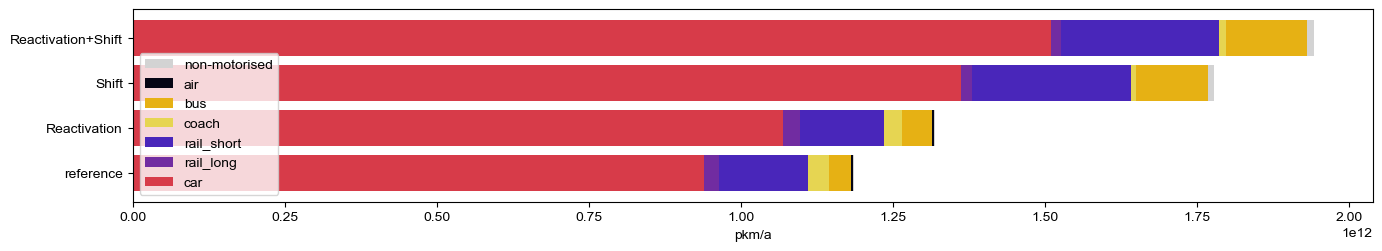

In [68]:
# Pkm as bar plot for entire Germany
fig, ax = plt.subplots(figsize=(16,2.5))
pkm_df = pd.DataFrame()
for s in scenarios:
    pkm_df[s] = pkm[s].sum()
pkm_df = pkm_df.rename(index={'walk': 'non-motorised'}).fillna(0)
modes = [m for m in colormap.keys() if m in pkm_df.index]
pkm_df.T[modes].plot.barh(stacked=True, width=0.8, ax=ax, legend=None,
                          color=[colormap[m] for m in modes])
ax.set_xlabel('pkm/a')
h,l = ax.get_legend_handles_labels()
plt.legend(h[::-1], l[::-1], loc='lower left')
plt.savefig(output_path + '_scenario_validation_regional/Germany_modal_split_pkm.png', dpi=dpi, bbox_inches = "tight")

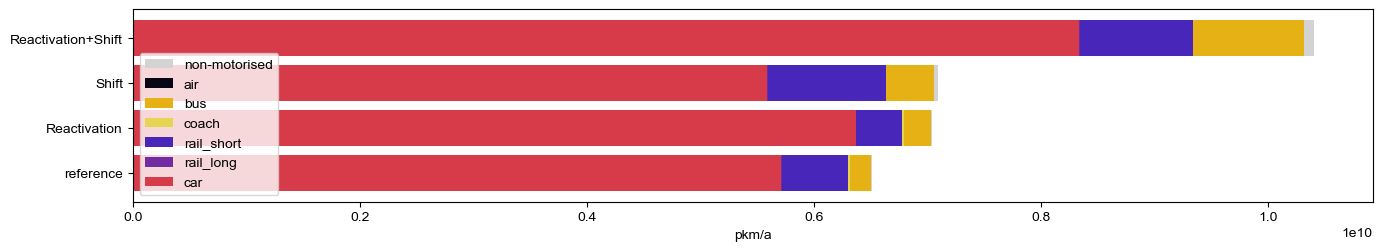

In [69]:
# Pkm as bar plot for the model region
fig, ax = plt.subplots(figsize=(16,2.5))
pkm_df = pd.DataFrame()
for s in scenarios:
    pkm_df[s] = pkm[s].loc[zone_ids].sum()
pkm_df = pkm_df.rename(index={'walk': 'non-motorised'}).fillna(0)
modes = [m for m in colormap.keys() if m in pkm_df.index]
pkm_df.T[modes].plot.barh(stacked=True, width=0.8, ax=ax, legend=None,
                          color=[colormap[m] for m in modes])
ax.set_xlabel('pkm/a')
h,l = ax.get_legend_handles_labels()
plt.legend(h[::-1], l[::-1], loc='lower left')
plt.savefig(output_path + '_scenario_validation_regional/'+region_name+'_modal_split_pkm.png', dpi=dpi, bbox_inches = "tight")

## Regional differences

In [ ]:
# Load pkm as NUTS3 aggregate
pkm = {}
for s in scenarios:
    df = pd.read_csv(output_path + s + '/pkm.csv')
    df = df.set_index(['origin', 'mode']).unstack('mode')['pkm'].dropna(how='all').fillna(0)
    pkm[s] = df[[mode for mode in df.columns if df[mode].sum()>df.sum().sum()*0.001]]

In [31]:
# Prepare zones to plot
zones = ref.zones.groupby('NUTS_ID').agg({'geometry': lambda g: g.union_all(),
                                          'population': 'sum', 'area': 'sum'})
zones = zones.set_geometry('geometry').set_crs(ref.epsg).to_crs(3857)

C:\Users\m.arnz\AppData\Local\Temp\ipykernel_14084\1571541286.py:2: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  zones = ref.zones.groupby('NUTS_ID').agg({'geometry': lambda g: g.unary_union,


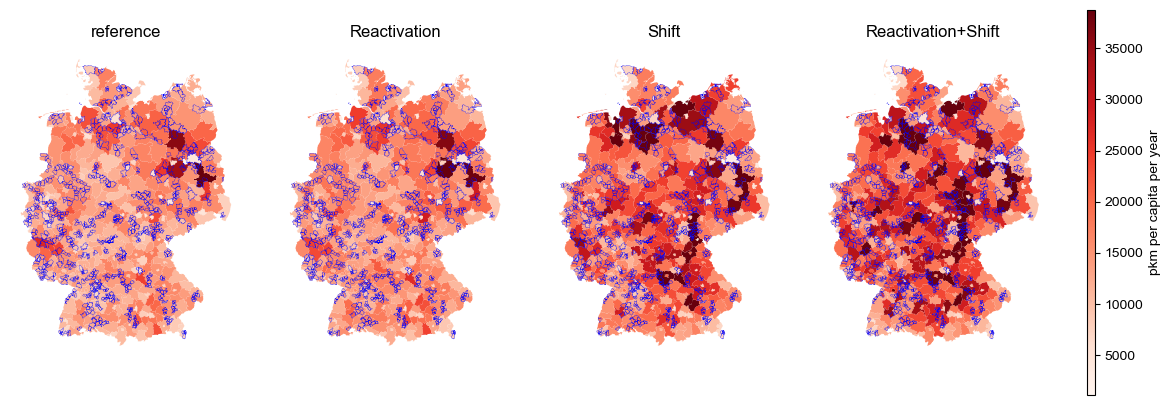

In [39]:
# Map the traffic intensity divided by population
fig, ax = plt.subplots(nrows=1, ncols=len(scenarios)+1, figsize=(14, 5),
                       gridspec_kw={'width_ratios': [len(scenarios)/(1-0.17)]*len(scenarios)+[0.17]})
vmin = 0
vmax = 0
for i in range(len(scenarios)):
    zones[scenarios[i]] = zones.merge(pkm[scenarios[i]].sum(axis=1).rename('pkm'),
                                      how='right', left_index=True, right_index=True)['pkm']
    zones[scenarios[i]] /= zones['population']
    if i == 0:
        vmax = zones[scenarios[i]].max()
        vmin = zones[scenarios[i]].min()
    plot = zones.plot(column=scenarios[i], cmap='Reds', missing_kwds={'color': 'lightgrey'},
                      vmin=vmin, vmax=vmax, legend=False, ax=ax[i])
    if 'Reactivation' scenarios[i]:
        ref.zones.to_crs(3857).loc[all_zone_ids, 'geometry'].plot(facecolor='none', edgecolor='blue', linewidth=.2, ax=ax[i])
    ax[i].set_title(scenarios[i])
    ax[i].set_axis_off()
fig.colorbar(ax[0].collections[0], cax=ax[-1], label="pkm per capita per year")
plt.savefig(output_path + '_scenario_validation_regional/Germany_map_pkm_population.png', dpi=dpi, bbox_inches="tight")